<a href="https://colab.research.google.com/github/meghana-anupoju/movie-recommender-system/blob/main/Movie_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install pandas
! pip install numpy
! pip install scikit-learn
! pip install matplotlib
! pip install seaborn

In [4]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [5]:
import pandas as pd
# Load the movie metadata CSV file, specifying the encoding
df = pd.read_csv("/content/imdb_top_1000.csv", low_memory=False, encoding='latin-1')


In [6]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [ ]:
#checking all the columns from datasets
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [ ]:
#we only need series title, genres, IMDB rating, meta score, no.of votes etc
movies = df[[ 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating',  'Meta_score', 'Director',
       'Star1',  'No_of_Votes', 'Gross']].copy()
print(movies)


                 Series_Title Released_Year Certificate  Runtime  \
0    The Shawshank Redemption          1994           A  142 min   
1               The Godfather          1972           A  175 min   
2             The Dark Knight          2008          UA  152 min   
3      The Godfather: Part II          1974           A  202 min   
4                12 Angry Men          1957           U   96 min   
..                        ...           ...         ...      ...   
995    Breakfast at Tiffany's          1961           A  115 min   
996                     Giant          1956           G  201 min   
997     From Here to Eternity          1953      Passed  118 min   
998                  Lifeboat          1944         NaN   97 min   
999              The 39 Steps          1935         NaN   86 min   

                        Genre  IMDB_Rating  Meta_score              Director  \
0                       Drama          9.3        80.0        Frank Darabont   
1                Crime,

In [ ]:
# Drop rows with missing values in important columns
movies = movies.dropna(subset=[   'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
        'No_of_Votes', 'Gross']).copy()



In [ ]:
#Extract genre names from JSON-like string

def parse_genre(genre_str):
    if pd.isna(genre_str):
        return []
    return [g.strip() for g in genre_str.split(',')]

#Apply the parsing function to each row

movies['genre_list'] = movies['Genre'].apply(parse_genre)

print (movies['genre_list'])



0                             [Drama]
1                      [Crime, Drama]
2              [Action, Crime, Drama]
3                      [Crime, Drama]
4                      [Crime, Drama]
                    ...              
990             [Drama, War, Western]
991          [Adventure, Comedy, War]
992    [Animation, Adventure, Family]
994          [Comedy, Music, Musical]
997             [Drama, Romance, War]
Name: genre_list, Length: 714, dtype: object


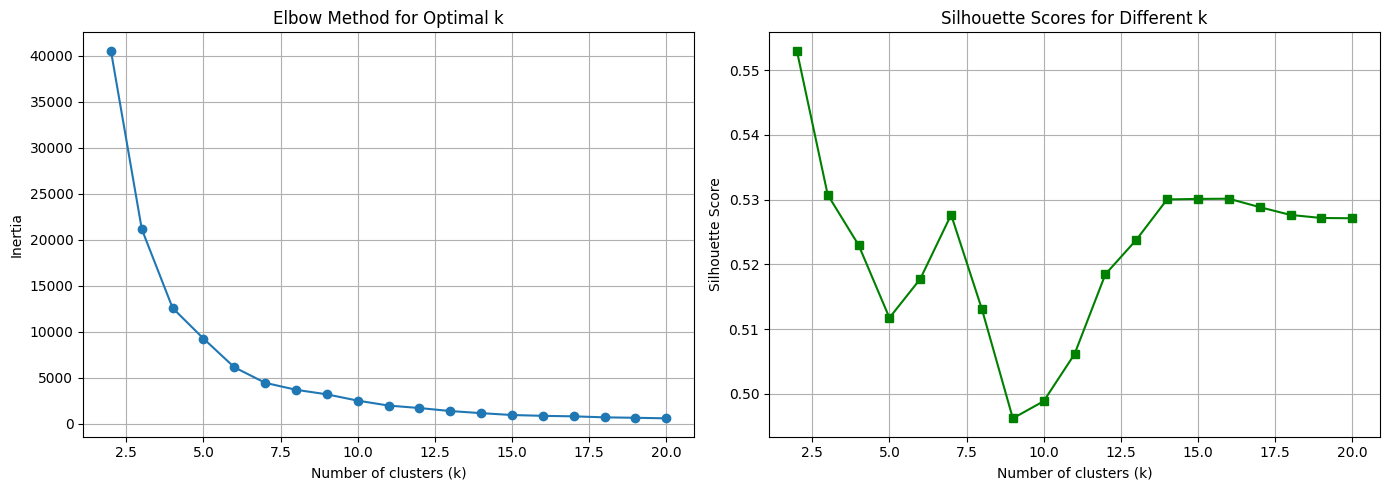

In [ ]:
# 1. Feature Selection and Engineering:
# Assuming you want to use 'IMDB_Rating' and 'Meta_score' as features:
features = movies[['IMDB_Rating', 'Meta_score']]

# Handle missing values (if any) - replace with 0 for now
features = features.fillna(0)

# 2. Assign to `final_features`:
final_features = features  # or final_features = features.values
# if your KMeans implementation requires a NumPy array


inertia_values = []
silhouette_scores = []
k_values = range(2, 21)

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42)
    kmeans_model.fit(final_features)
    inertia_values.append(kmeans_model.inertia_)
    silhouette_scores.append(silhouette_score(final_features, kmeans_model.labels_))

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(k_values, inertia_values, marker='o')
axs[0].set_title('Elbow Method for Optimal k')
axs[0].set_xlabel('Number of clusters (k)')
axs[0].set_ylabel('Inertia')
axs[0].grid(True)

axs[1].plot(k_values, silhouette_scores, marker='s', color='green')
axs[1].set_title('Silhouette Scores for Different k')
axs[1].set_xlabel('Number of clusters (k)')
axs[1].set_ylabel('Silhouette Score')
axs[1].grid(True)

plt.tight_layout()
plt.show()

<ipython-input-24-59d7d656163a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


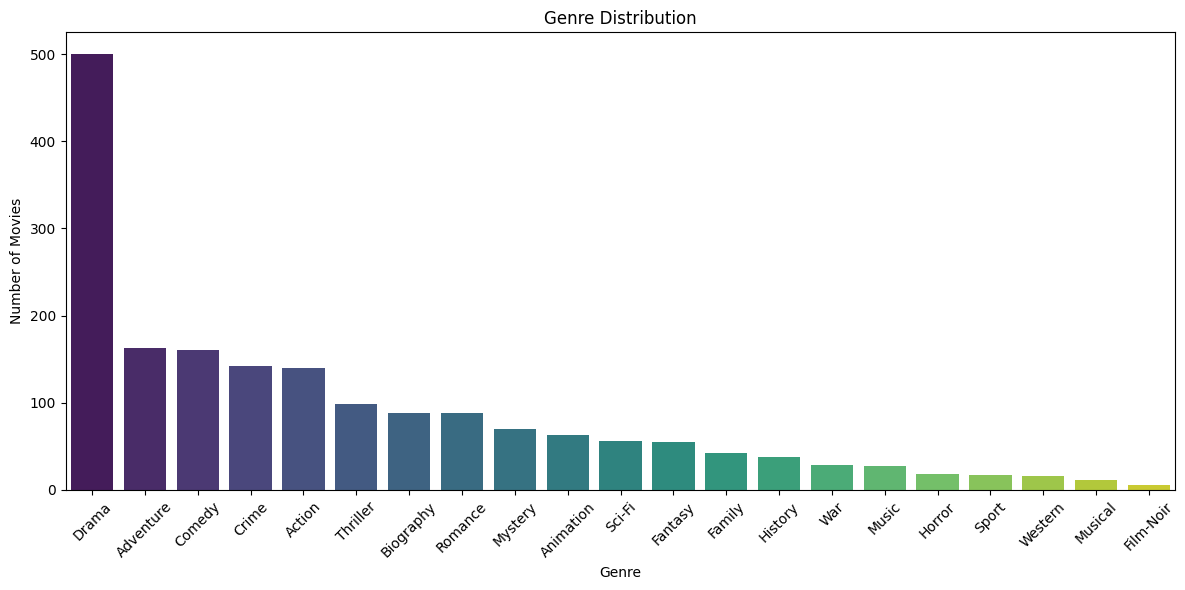

In [ ]:


# Genre Bar Plot
genre_counts = movies['genre_list'].explode().value_counts().sort_values(ascending=False)
#print(genre_counts)
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Genre Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

In [ ]:
# This turns genre lists into binary features
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(movies['genre_list'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)
print(genre_df)


     Action  Adventure  Animation  Biography  Comedy  Crime  Drama  Family  \
0         0          0          0          0       0      0      1       0   
1         0          0          0          0       0      1      1       0   
2         1          0          0          0       0      1      1       0   
3         0          0          0          0       0      1      1       0   
4         0          0          0          0       0      1      1       0   
..      ...        ...        ...        ...     ...    ...    ...     ...   
709       0          0          0          0       0      0      1       0   
710       0          1          0          0       1      0      0       0   
711       0          1          1          0       0      0      0       1   
712       0          0          0          0       1      0      0       0   
713       0          0          0          0       0      0      1       0   

     Fantasy  Film-Noir  ...  Horror  Music  Musical  Mystery  

In [ ]:
# We scale IMDB_Rating and Meta_score to range [0, 1]
scaler = MinMaxScaler()
# Changed 'vote_average' and 'popularity' to 'IMDB_Rating' and 'Meta_score' respectively
scaled_features = scaler.fit_transform(movies[['IMDB_Rating', 'Meta_score','No_of_Votes']])
scaled_df = pd.DataFrame(scaled_features, columns=['IMDB_Rating', 'Meta_score','No_of_Votes'])
print(scaled_df)

     IMDB_Rating  Meta_score  No_of_Votes
0       1.000000    0.722222     1.000000
1       0.941176    1.000000     0.688188
2       0.823529    0.777778     0.982795
3       0.823529    0.861111     0.476609
4       0.823529    0.944444     0.286734
..           ...         ...          ...
709     0.000000    0.680556     0.002120
710     0.000000    0.305556     0.008676
711     0.000000    0.513889     0.060909
712     0.000000    0.944444     0.006524
713     0.000000    0.791667     0.007828

[714 rows x 3 columns]


In [ ]:
#Combine all features into one matrix
final_features = pd.concat([genre_df, scaled_df], axis=1)
#print(final_features)

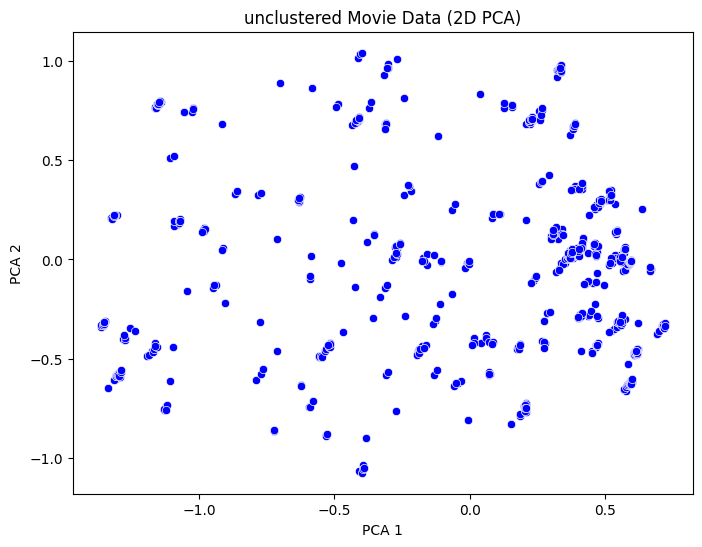

In [ ]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(final_features)

plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], color='blue')
plt.title('unclustered Movie Data (2D PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

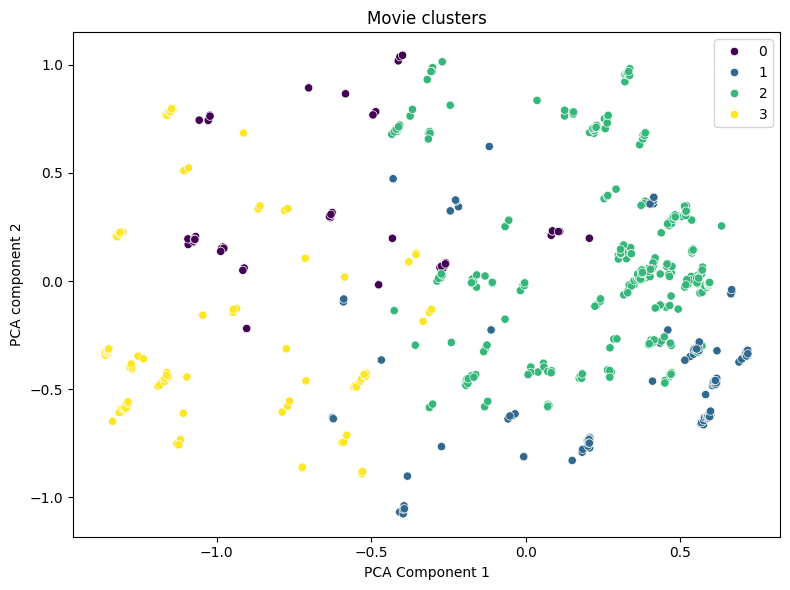

In [ ]:
from sklearn.cluster import KMeans
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(final_features)

kmeans_model = KMeans(n_clusters=4, random_state=42)
clusters = kmeans_model.fit_predict(final_features)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=clusters, palette='viridis')

plt.title('Movie clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA component 2')

plt.tight_layout()
plt.show()


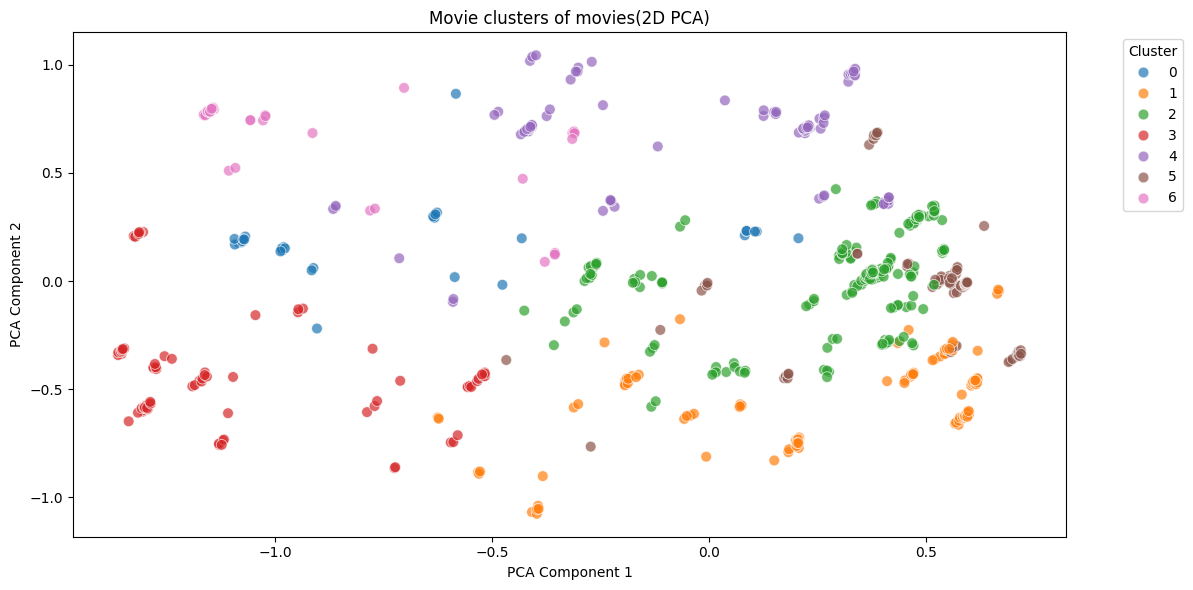

In [ ]:
#step 2: fit kmeans and assign clusters
optimal_K = 7
kmeans = KMeans(n_clusters=optimal_K, random_state=42)
movies['cluster'] = kmeans.fit_predict(final_features)
#step3: plot scatter with cluster color
plt.figure(figsize=(12,6))
sns.scatterplot(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    hue=movies['cluster'],
    palette='tab10',
    s=60,

    alpha=0.7
)
plt.title('Movie clusters of movies(2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<ipython-input-55-3fa4d87c8341>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=movies['cluster'], palette='coolwarm')


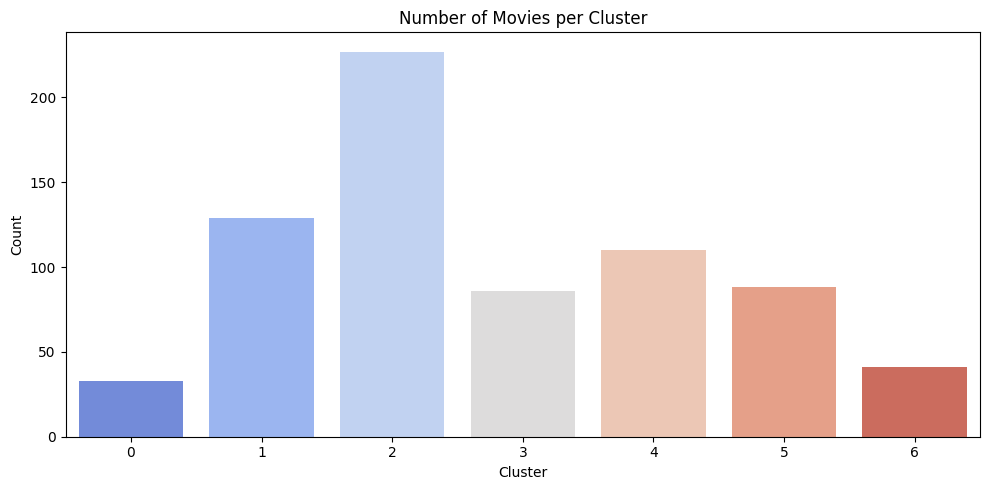

In [ ]:
optimal_K = 7
kmeans = KMeans(n_clusters=optimal_K, random_state=42)
movies['cluster'] = kmeans.fit_predict(final_features)


# Plot how many movies per cluster
plt.figure(figsize=(10, 5))
sns.countplot(x=movies['cluster'], palette='coolwarm')
plt.title('Number of Movies per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [28]:




#Define recommendation function
def recommend_movies(movie_title, movies, n=5): # Pass 'movies' as an argument
    """
    Recommend similar movies based on genre, popularity, and rating using clustering.

    Parameters:
        movie_title (str): Title of the movie to base recommendations on.
        movies (pd.DataFrame): The DataFrame containing movie data. # Add movies to docstring
        n (int): Number of similar movies to return.

    Returns:
        pd.DataFrame: Top N recommended movies in the same cluster.
    """
    # Lowercase comparison for robust matching
    target = movies[movies['Series_Title'].str.lower() == movie_title.lower()] # Changed 'title' to 'Series_Title'

    if target.empty:
        return f" Movie titled '{movie_title}' not found in dataset."

    # Get the cluster of the target movie
    cluster_id = target['cluster'].values[0]

    # Get all movies from the same cluster
    similar_movies = movies[(movies['cluster'] == cluster_id) &
                            (movies['Series_Title'].str.lower() != movie_title.lower())] # Changed 'title' to 'Series_Title'

    # Return top N based on vote_average and popularity
    # Assuming you have these columns
    # If not, replace with the actual columns you want to use
    return similar_movies[['Series_Title', 'IMDB_Rating', 'No_of_Votes']].sort_values( # Changed column names
        by=['IMDB_Rating', 'No_of_Votes'], ascending=False).head(n) # Changed column names




# Example usage:
print(" Recommended movies similar to 'The Godfather':")
print(recommend_movies("The Dark Knight", movies, n=5)) # Pass 'movies' when calling the function

 Recommended movies similar to 'The Godfather':
              Series_Title  IMDB_Rating  No_of_Votes
1            The Godfather          9.2      1620367
3   The Godfather: Part II          9.0      1129952
4             12 Angry Men          9.0       689845
6             Pulp Fiction          8.9      1826188
27                   Se7en          8.6      1445096


In [ ]:
pip install streamlit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 9.0 MB/s eta 0:00:00


In [1]:
!pip install streamlit pyngrok --quiet





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.8 MB/s eta 0:00:00


In [25]:
%%writefile app.py
import streamlit as st

# Dummy recommend_movies function (replace with your real one)
def recommend_movies(movie_name, n=5):
    return ["The Godfather",
        "The Dark Knight",
 "The Godfather: Part II ",
           "12 Angry Men  ",
          "Pulp Fiction " ]

st.title("🎬 Movie Recommender System")
movie_name = st.text_input("Toy story:")
if st.button("Recommend"):
    recommendations = recommend_movies(movie_name, n=5)
    st.write("Recommended Movies:")
    for movie in recommendations:
        st.write(f"- {movie}")


Overwriting app.py


In [22]:
from pyngrok import ngrok

# Set your ngrok auth token
ngrok.set_auth_token("2tzHJs80GIMPdQm78EkGwtRXaz5_6YLjwPAaifTvg99wEbkvA")


In [26]:
from pyngrok import ngrok

# Kill any running tunnels
ngrok.kill()

# Create a tunnel to the streamlit port 8501
# Specify 'addr' instead of 'port'
public_url = ngrok.connect(addr=8501)
print(f"Public URL: {public_url}")

# Run streamlit app
!streamlit run app.py &> /dev/null &

Public URL: NgrokTunnel: "https://31c5-34-106-141-143.ngrok-free.app" -> "http://localhost:8501"
